In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/SUN/PIL-main /content/

In [ ]:

!cp -r "/content/drive/MyDrive//SUN/LEVEL3FITS" /content/

In [ ]:
!cp -r "/content/drive/My Drive/SUN/meudon_new" /content/

In [ ]:
%cd /content/PIL-main
!pip install astropy scikit-image plotly imageio

/content/PIL-main


In [ ]:
############################################
# 1. Imports
############################################

import os
import re
import random
import torch
import numpy as np
from astropy.io import fits
from skimage.transform import resize
from PIL import Image

from scripts.neutralliner import NeutralLiner
from scripts.imagedata import ImageData
from scripts.config import FITS_SHAPE


############################################
# 2. Paths
############################################

MEUDON_PATH = "/content/meudon_new"
MCINTOSH_PATH = "/content/LEVEL3FITS"

SAVE_BASE = "/content/drive/MyDrive/new_meudon_step_sizes/new_meudon_STEP_SIZE_8" #change for different step sizes

os.makedirs(SAVE_BASE, exist_ok=True)


############################################
# 3. Index McIntosh files by CR number
############################################

mcintosh_index = {}

for f in os.listdir(MCINTOSH_PATH):
    match = re.search(r'cr(\d+)', f)
    if match:
        cr = int(match.group(1))
        mcintosh_index[cr] = os.path.join(MCINTOSH_PATH, f)

print("McIntosh maps indexed:", len(mcintosh_index))


############################################
# 4. Find available Meudon CRs
############################################

meudon_crs = []

for f in os.listdir(MEUDON_PATH):
    if f.endswith(".png"):
        cr = int(f.split(".")[0])
        meudon_crs.append(cr)

meudon_crs = sorted(meudon_crs)

print("Available Meudon CRs:", len(meudon_crs))


############################################
# 5. Select CRs for training
############################################

# N_CRS = 10

# selected_crs = random.sample(meudon_crs, N_CRS)
selected_crs = [1355, 1373, 1387]

print("Selected CRs:", selected_crs)


############################################
# 6. Training parameters
############################################

MODELS_PER_CR = 100
EPOCHS = 3000

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)


McIntosh maps indexed: 611
Available Meudon CRs: 1048
Selected CRs: [1355, 1373, 1387]
Using device: cuda


In [ ]:
############################################
# 7. Function to load dataset for one CR
############################################

def build_image_data(cr):

    meudon_file = os.path.join(MEUDON_PATH, f"{cr}.png")
    mcintosh_file = mcintosh_index[cr]

    # --------------------------
    # Load Meudon filament (PNG)
    # --------------------------
    img = Image.open(meudon_file).convert("L")
    filament = np.array(img)

    # Normalize
    filament = (filament - filament.min()) / (filament.max() - filament.min())

    # Invert (filaments are dark)
    filament = 1 - filament

    # Resize
    filament = resize(
        filament.astype(float),
        FITS_SHAPE,
        anti_aliasing=True
    )

    filament = np.flipud(filament)

    # Threshold → binary
    filament = filament > 0.7


    # --------------------------
    # Load McIntosh polarity
    # --------------------------
    with fits.open(mcintosh_file) as hdul:
        img = hdul[0].data[10:-10, 10:-10]

    sign = np.array(img == 7)

    sign = resize(
        sign.astype(float),
        FITS_SHAPE,
        anti_aliasing=True
    )

    sign = sign * 2 - 1


    # --------------------------
    # Create ImageData object
    # --------------------------
    img_data = ImageData(filament, data_mode="img")
    img_data.target_img = sign


    # --------------------------
    # Fix dimensions (important)
    # --------------------------
    h, w = img_data.img_array.shape
    img_data.height = h
    img_data.width = w

    return img_data


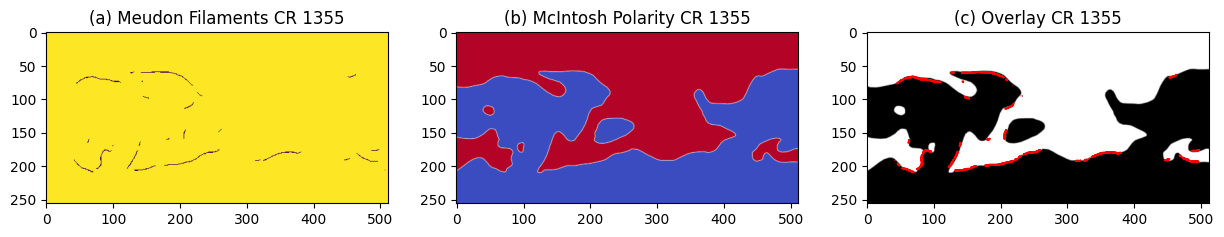

In [ ]:
img = build_image_data(1355)
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].imshow(img.img_array, cmap='viridis')
axes[0].set_title('(a) Meudon Filaments CR 1355')
axes[1].imshow(img.target_img, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('(b) McIntosh Polarity CR 1355')

axes[2].imshow(img.target_img, cmap='gray')
axes[2].set_title('(c) Overlay CR 1355')
axes[2].contour(img.img_array,
                levels=[0],
                colors='red',
                linewidths=1.5)

In [ ]:
############################################
# 8. TRAINING LOOP
############################################

for cr in selected_crs:

    if cr not in mcintosh_index:
        print("Skipping CR", cr, "(no McIntosh)")
        continue

    print("\n==============================")
    print("Training CR", cr)
    print("==============================")

    img = build_image_data(cr)

    CR_SAVE = f"{SAVE_BASE}/model_CR_{cr}"
    os.makedirs(CR_SAVE, exist_ok=True)

    ########################################
    # Train multiple models per CR
    ########################################

    for k in range(MODELS_PER_CR):

        model_path = f"{CR_SAVE}/model_{k}.pth"

        if os.path.exists(model_path):
            print(f"Model {k} already exists, skipping")
            continue

        print(f"\nTraining model {k} for CR {cr}")

        help_step_size=None

        model = NeutralLiner(
            image_list=[img],
            lr=5e-3,
            help_step_size=8,   # you can set None later
            device=device
        )

        # if help_step_size is None and not hasattr(model, "targets"): #Activate for NONE case
        #   model.targets = [None] * len(model.image_list)

        model.to(device)

        model.start_training(
            num_epochs=EPOCHS,
            need_plot=False
        )

        ####################################
        # Save trained model
        ####################################
        torch.save(
            model.state_dict(),
            model_path
        )

        print("Saved:", model_path)


Training CR 1355
Model 0 already exists, skipping
Model 1 already exists, skipping
Model 2 already exists, skipping
Model 3 already exists, skipping
Model 4 already exists, skipping
Model 5 already exists, skipping
Model 6 already exists, skipping
Model 7 already exists, skipping
Model 8 already exists, skipping
Model 9 already exists, skipping
Model 10 already exists, skipping
Model 11 already exists, skipping
Model 12 already exists, skipping
Model 13 already exists, skipping
Model 14 already exists, skipping
Model 15 already exists, skipping
Model 16 already exists, skipping
Model 17 already exists, skipping
Model 18 already exists, skipping
Model 19 already exists, skipping
Model 20 already exists, skipping
Model 21 already exists, skipping
Model 22 already exists, skipping
Model 23 already exists, skipping
Model 24 already exists, skipping
Model 25 already exists, skipping
Model 26 already exists, skipping
Model 27 already exists, skipping
Model 28 already exists, skipping
Model 

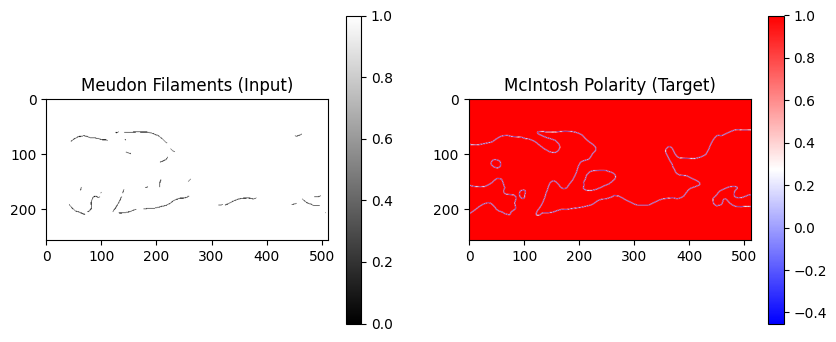

In [ ]:
import matplotlib.pyplot as plt

cr = 1355  # or any CR you selected
img_data = build_image_data(cr)

filament = img_data.img_array
target = img_data.target_img

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Meudon Filaments (Input)")
plt.imshow(filament, cmap='gray')
plt.colorbar()

plt.subplot(1,2,2)
plt.title("McIntosh Polarity (Target)")
plt.imshow(target, cmap='bwr')  # blue-red for ±1
plt.colorbar()

plt.show()

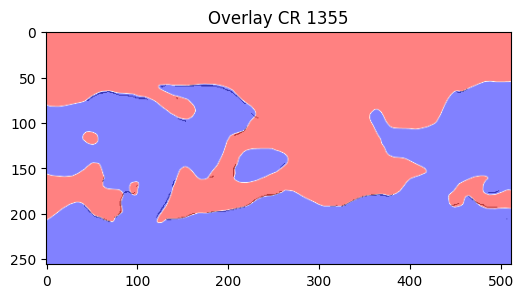

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(target, cmap='bwr', alpha=0.7)
plt.imshow(filament, cmap='gray', alpha=0.3)

plt.title(f"Overlay CR {cr}")
plt.show()

Processing CR 1355...
Processing CR 1373...
Processing CR 1387...


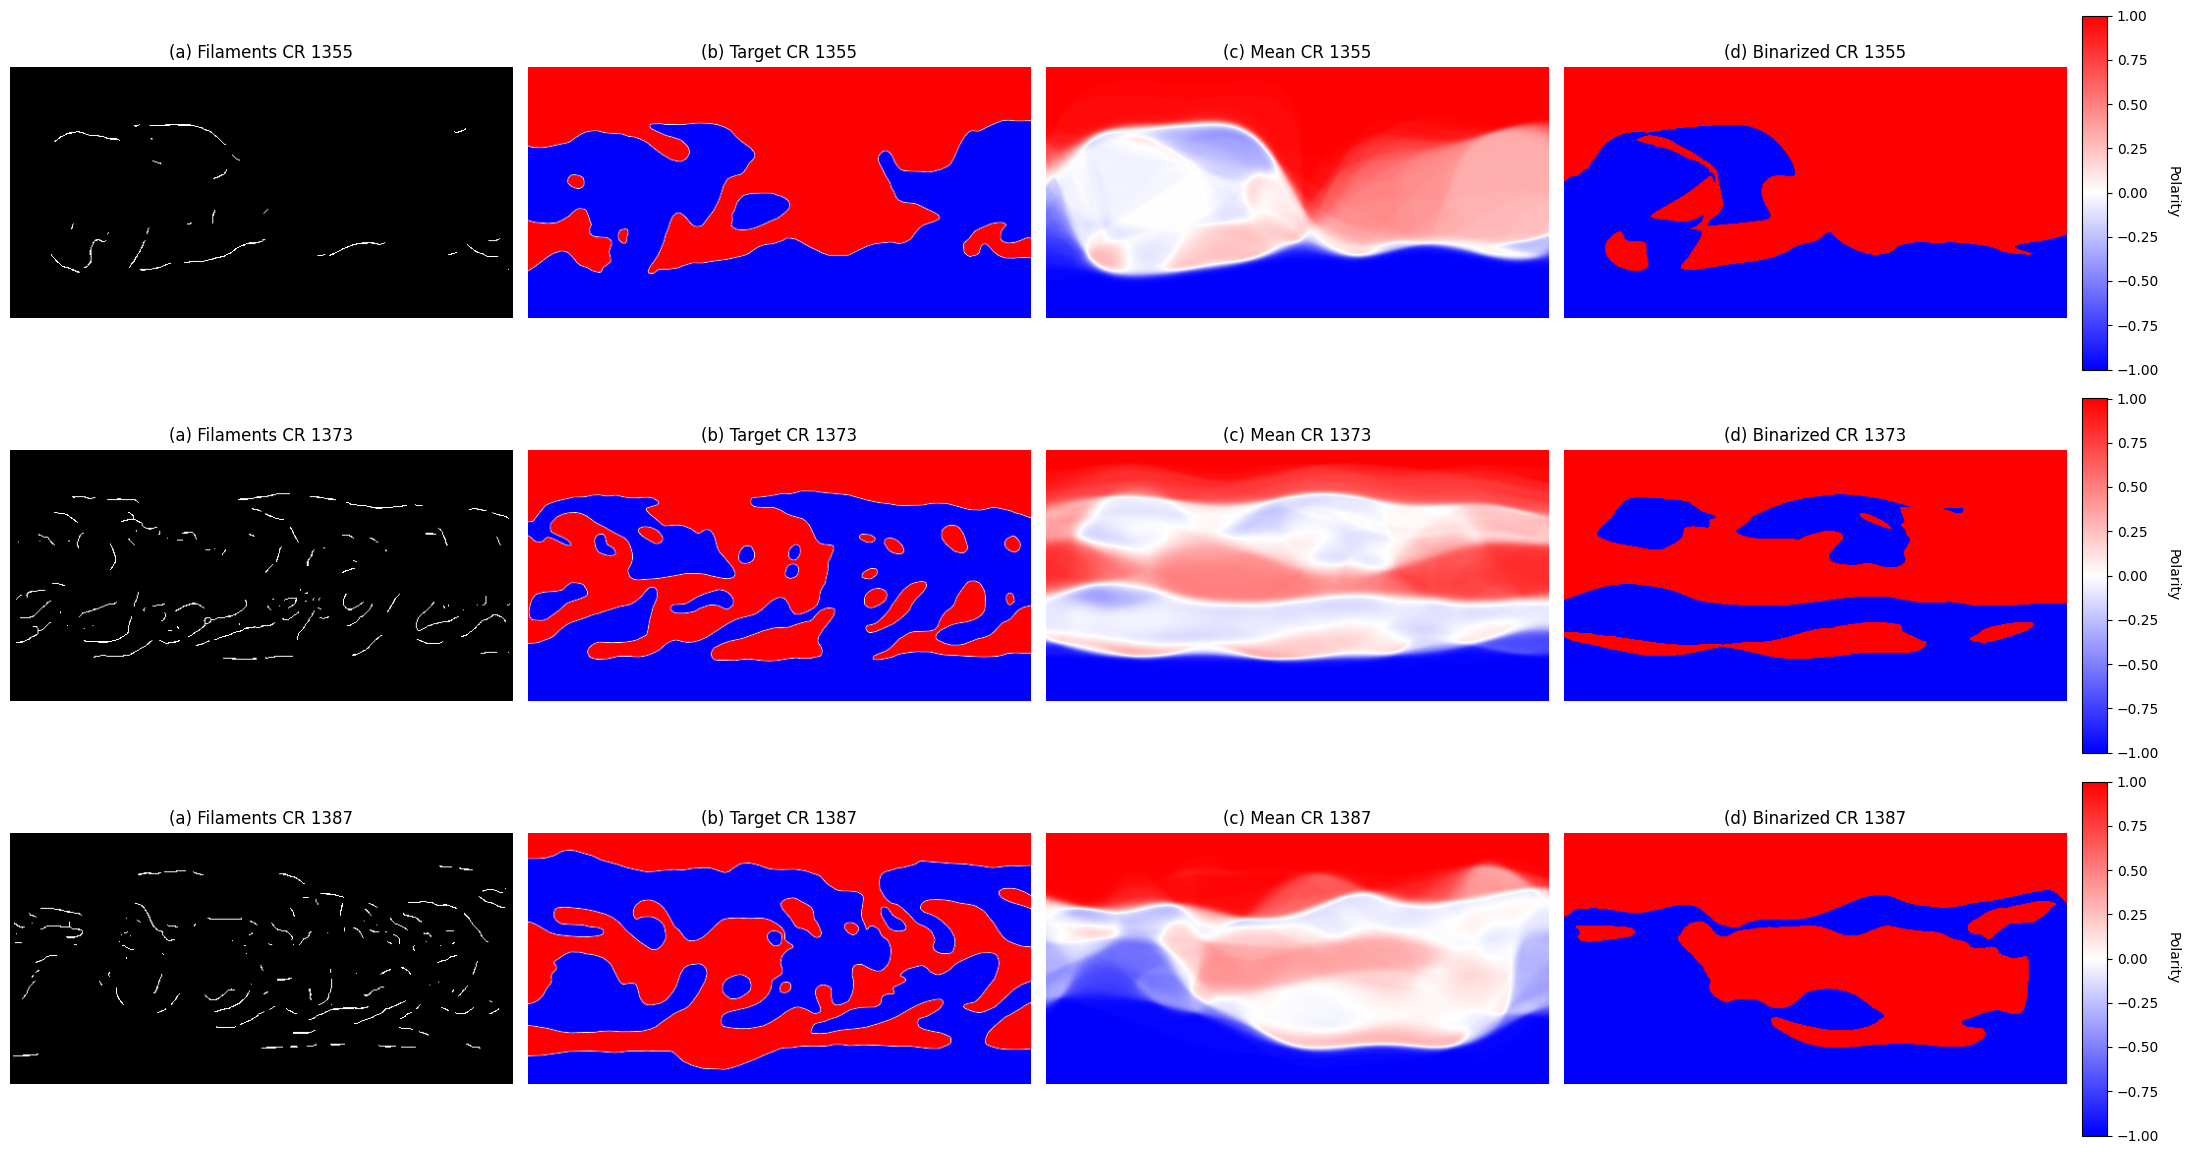

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np
import torch

selected_crs = [1355, 1373, 1387]

# =====================================================
# 5 columns:
# Filament | Target | Mean | Binarized | Colorbar
# =====================================================

fig, axes = plt.subplots(
    len(selected_crs),
    5,
    figsize=(22, 4*len(selected_crs)),
    gridspec_kw={
        'width_ratios':[1,1,1,1,0.05]
    }
)

for row, cr in enumerate(selected_crs):

    print(f"Processing CR {cr}...")

    img = build_image_data(cr)

    model_dir = f"{SAVE_BASE}/model_CR_{cr}"

    preds = []

    # ===============================================
    # Ensemble prediction
    # ===============================================

    for f in os.listdir(model_dir):

        if not f.endswith(".pth"):
            continue

        model = NeutralLiner(
            image_list=[img],
            lr=5e-3,
            help_step_size=32,
            device=device
        )

        model.load_state_dict(
            torch.load(
                os.path.join(model_dir, f),
                map_location=device
            )
        )

        model.to(device)

        pred = model.test_model(
            need_plot=False
        )[0]

        preds.append(
            pred.cpu().numpy()
        )

    pred = np.mean(preds, axis=0)

    pred_map = pred.reshape(
        img.img_array.shape
    )

    binary_map = np.sign(pred_map)

    # ===============================================
    # (a) Filaments
    # ===============================================

    filament_display = (1 - img.img_array)**0.25

    axes[row,0].imshow(
        filament_display,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row,0].set_title(
        f"(a) Filaments CR {cr}"
    )

    axes[row,0].axis("off")

    # ===============================================
    # (b) Target
    # ===============================================

    axes[row,1].imshow(
        img.target_img,
        cmap="bwr",
        vmin=-1,
        vmax=1
    )

    axes[row,1].set_title(
        f"(b) Target CR {cr}"
    )

    axes[row,1].axis("off")

    # ===============================================
    # (c) Mean Prediction
    # ===============================================

    im = axes[row,2].imshow(
        pred_map,
        cmap="bwr",
        vmin=-1,
        vmax=1
    )

    axes[row,2].set_title(
        f"(c) Mean CR {cr}"
    )

    axes[row,2].axis("off")

    # ===============================================
    # (d) Binarized
    # ===============================================

    axes[row,3].imshow(
        binary_map,
        cmap="bwr",
        vmin=-1,
        vmax=1
    )

    axes[row,3].set_title(
        f"(d) Binarized CR {cr}"
    )

    axes[row,3].axis("off")

    # ===============================================
    # Dedicated colorbar column
    # ===============================================

    cax = axes[row,4]

    cbar = fig.colorbar(
        im,
        cax=cax
    )

    cbar.set_label(
        "Polarity",
        rotation=270,
        labelpad=15
    )

# =====================================================
# Figure title
# =====================================================



plt.tight_layout(
    rect=[0,0,1,0.97]
)

plt.show()

In [ ]:
import os
import numpy as np
import torch

############################################
# Metric function
############################################

def compute_metrics(pred_map, target_img):
    """
    Binarizes prediction and target at zero, then computes
    IoU, Dice, Precision, Recall, macro-averaged over the
    two polarity classes (+1 and -1).
    """
    pred_bin = (pred_map > 0).astype(int)
    target_bin = (target_img > 0).astype(int)

    def class_metrics(pred, target):
        TP = np.sum((pred == 1) & (target == 1))
        FP = np.sum((pred == 1) & (target == 0))
        FN = np.sum((pred == 0) & (target == 1))

        iou = TP / (TP + FP + FN + 1e-8)
        dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        return np.array([iou, dice, precision, recall])

    # class "+1" (positive polarity)
    pos = class_metrics(pred_bin, target_bin)
    # class "-1" (negative polarity) -- flip labels
    neg = class_metrics(1 - pred_bin, 1 - target_bin)

    # macro average across both classes
    return (pos + neg) / 2.0


############################################
# Evaluate one step-size experiment
############################################

def evaluate_step_size(save_base, help_step_size, selected_crs):
    all_metrics = []

    for cr in selected_crs:
        img = build_image_data(cr)
        model_dir = f"{save_base}/model_CR_{cr}"

        preds = []
        for f in os.listdir(model_dir):
            if not f.endswith(".pth"):
                continue

            model = NeutralLiner(
                image_list=[img],
                lr=5e-3,
                help_step_size=help_step_size,
                device=device
            )
            model.load_state_dict(
                torch.load(os.path.join(model_dir, f), map_location=device)
            )
            model.to(device)

            pred = model.test_model(need_plot=False)[0]
            preds.append(pred.cpu().numpy())

        pred = np.mean(preds, axis=0)
        pred_map = pred.reshape(img.img_array.shape)

        m = compute_metrics(pred_map, img.target_img)
        all_metrics.append(m)
        print(f"  CR {cr}: IoU={m[0]:.3f}  Dice={m[1]:.3f}  "
              f"Precision={m[2]:.3f}  Recall={m[3]:.3f}")

    return np.mean(all_metrics, axis=0)


############################################
# Run for all four step-size configurations
############################################

BASE_ROOT = "/content/drive/MyDrive/new_meudon_step_sizes"

configs = {
    "Step 1":  (f"{BASE_ROOT}/new_meudon_STEP_SIZE_1",   1),
    "Step 8":  (f"{BASE_ROOT}/new_meudon_STEP_SIZE_8",   8),
    "Step 32": (f"{BASE_ROOT}/new_meudon_STEP_SIZE_32",  32),
    "No PINN": (f"{BASE_ROOT}/new_meudon_STEP_SIZE_None", None),
}

results_table = {}

for name, (save_base, step) in configs.items():
    print(f"\n=== {name} (help_step_size={step}) ===")
    results_table[name] = evaluate_step_size(save_base, step, selected_crs)

############################################
# Print final markdown table
############################################

print("\n| Model   | IoU   | Dice  | Precision | Recall |")
print("|---------|-------|-------|-----------|--------|")
for name, m in results_table.items():
    print(f"| {name:7s} | {m[0]:.3f} | {m[1]:.3f} | {m[2]:.3f}     | {m[3]:.3f}  |")


=== Step 1 (help_step_size=1) ===
  CR 1355: IoU=0.929  Dice=0.963  Precision=0.963  Recall=0.963
  CR 1373: IoU=0.869  Dice=0.930  Precision=0.930  Recall=0.930
  CR 1387: IoU=0.802  Dice=0.890  Precision=0.890  Recall=0.891

=== Step 8 (help_step_size=8) ===
  CR 1355: IoU=0.924  Dice=0.960  Precision=0.961  Recall=0.960
  CR 1373: IoU=0.854  Dice=0.921  Precision=0.921  Recall=0.921
  CR 1387: IoU=0.800  Dice=0.889  Precision=0.888  Recall=0.889

=== Step 32 (help_step_size=32) ===
  CR 1355: IoU=0.873  Dice=0.932  Precision=0.932  Recall=0.932
  CR 1373: IoU=0.785  Dice=0.880  Precision=0.880  Recall=0.880
  CR 1387: IoU=0.683  Dice=0.811  Precision=0.812  Recall=0.811

=== No PINN (help_step_size=None) ===
  CR 1355: IoU=0.697  Dice=0.821  Precision=0.834  Recall=0.824
  CR 1373: IoU=0.507  Dice=0.673  Precision=0.678  Recall=0.675
  CR 1387: IoU=0.379  Dice=0.550  Precision=0.553  Recall=0.553

| Model   | IoU   | Dice  | Precision | Recall |
|---------|-------|-------|---------